# LIBRARIES

In [8]:
import sys
import os

# Agrega el directorio anterior al sys.path
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import my_module as mm
from scipy import stats
import importlib
import scipy.linalg as la
from getdist import MCSamples, plots
from scipy.constants import c

#Refresh the changes made on my_module files
importlib.reload(mm)


#Matplotlib parameters

plt.rcParams.update({
    # Font
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # Or your preferred from the list
    "font.size": 14,                 # Base font size for all text

    # Axes labels & title sizes
    "axes.titlesize": 16,
    "axes.labelsize": 14,

    # Tick parameters
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

})

from matplotlib.lines import Line2D

# Define custom legend entries (no markers, no lines, just colored text)
labels = ["Pantheon+", "DES 5yr"]
colors = ["chocolate", "darkgreen"]

# Create fake handles for legend
custom_handles = [
    Line2D([0], [0], color='none', marker='None', label=label)
    for label in labels
]

plt.rcParams['text.usetex'] = True

def tripp_estimator(model, data):

    if model=='DES':
        alpha = 0.161
        beta = 3.12
        gamma = 0.038

    elif model=='BS21':
        alpha = 0.148
        beta = 3.09
        gamma = -0.003

    elif model=='G10':
        alpha = 0.153
        beta = 2.98
        gamma = 0.054

    data['MU_{}'.format(model)] = data['mB'] + (alpha * data['x1']) - (beta * data['c']) + (data['sign'] * gamma/2) + 19.365

    return None

# Data

In [9]:
#Pantheon+ data import
data_Pan, cov_Pan = mm.data_import.Pantheon_data(cut=False)

#DES data import
data_DES, cov_DES = mm.data_import.DES_data(cut=False)

#Parameter for Tripp estimator
data_Pan['sign'] = np.where(data_Pan['HOST_LOGMASS'] < 10, -1, 1)
data_DES['sign'] = np.where(data_DES['HOST_LOGMASS'] < 10, -1, 1)

#Sort data by redshift
data_DES = data_DES.sort_values(by='zHD')
data_Pan = data_Pan.sort_values(by='zHD')

#Tripp estimator for each model and dataset
tripp_estimator('DES', data_Pan)
tripp_estimator('BS21', data_Pan)
tripp_estimator('G10', data_Pan)
tripp_estimator('DES', data_DES)
tripp_estimator('BS21', data_DES)
tripp_estimator('G10', data_DES)

common_data = data_Pan.merge(
    data_DES,
    on=['zHD', 'IDSURVEY'],
    how='inner',
    suffixes=('_Pan', '_DES')
)

In [10]:
text_folder = '../../text/images/'

In [11]:
temp_mb = -2.5 * np.log10(data_Pan['x0'])

temp = data_Pan['mB'] - temp_mb

temp

0       10.634996
1       10.634995
2       10.635014
3       10.634972
4       10.634976
          ...    
1696    10.635018
1697    10.634987
1698    10.634990
1699    10.634979
1700    10.635020
Length: 1701, dtype: float64

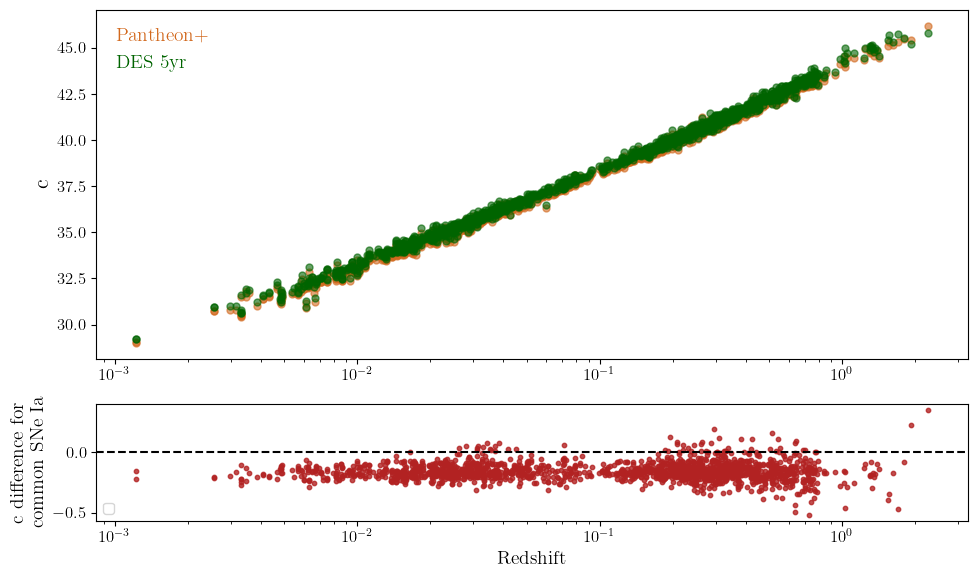

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

# Plotting parameters
ax1.plot(data_Pan['zHD'], data_Pan['MU_SH0ES'], 'o', label='Pantheon+', markersize=5, color='chocolate', alpha=0.6)
ax1.plot(data_Pan['zHD'], data_Pan['MU_BS21'], 'o', label='DES 5yr', markersize=5, color='darkgreen', alpha=0.6)
ax1.set_xscale('log')
ax1.set_ylabel('c', fontsize=16)
ax1.legend(fontsize=16)
leg = ax1.legend(handles=custom_handles, handlelength=0, handletextpad=0.1, frameon=False)

for text, color in zip(leg.get_texts(), colors):
    text.set_color(color)

# Difference for common SNe Ia
ax2.scatter(data_Pan['zHD'], data_Pan['MU_SH0ES'] - data_Pan['MU_DES'], color='firebrick', s=10, alpha=0.8)
ax2.axhline(0, color='black', linestyle='--')  # Línea en y=0 para referencia
ax2.set_xscale('log')
#ax2.set_ylim(-0.2, 0.3)
ax2.set_xlabel('Redshift')
ax2.set_ylabel(r'c difference for' '\n' 'common SNe Ia')
ax2.legend(loc='lower left', fontsize=10)

plt.tight_layout()
#plt.savefig(text_folder + 'c_parameter.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
np.mean(data_Pan['MU_SH0ES'] - data_Pan['MU_DES'])

-0.15595178687536568

# Parameters Comparision

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


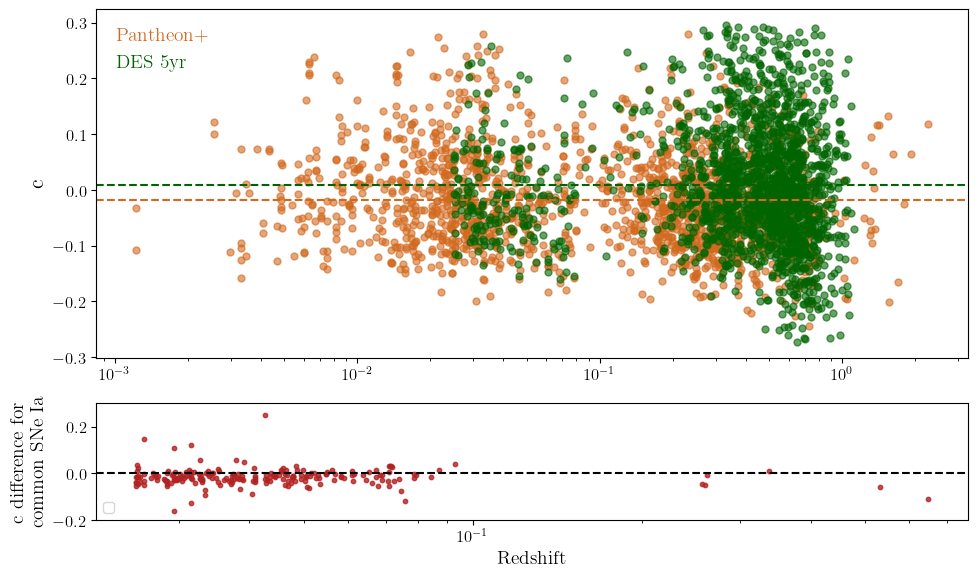

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

# Plotting parameters
ax1.plot(data_Pan['zHD'], data_Pan['c'], 'o', label='Pantheon+', markersize=5, color='chocolate', alpha=0.6)
ax1.plot(data_DES['zHD'], data_DES['c'], 'o', label='DES 5yr', markersize=5, color='darkgreen', alpha=0.6)
ax1.axhline(y=np.mean(data_Pan['c']), color='chocolate', linestyle='--')
ax1.axhline(y=np.mean(data_DES['c']), color='darkgreen', linestyle='--')
ax1.set_xscale('log')
ax1.set_ylabel('c', fontsize=16)
ax1.legend(fontsize=16)
leg = ax1.legend(handles=custom_handles, handlelength=0, handletextpad=0.1, frameon=False)

for text, color in zip(leg.get_texts(), colors):
    text.set_color(color)

# Difference for common SNe Ia
ax2.scatter(common_data['zHD'], common_data['c_Pan'] - common_data['c_DES'], color='firebrick', s=10, alpha=0.8)
ax2.axhline(0, color='black', linestyle='--')  # Línea en y=0 para referencia
ax2.set_xscale('log')
ax2.set_ylim(-0.2, 0.3)
ax2.set_xlabel('Redshift')
ax2.set_ylabel(r'c difference for' '\n' 'common SNe Ia')
ax2.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig(text_folder + 'c_parameter.png', dpi=300, bbox_inches='tight')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


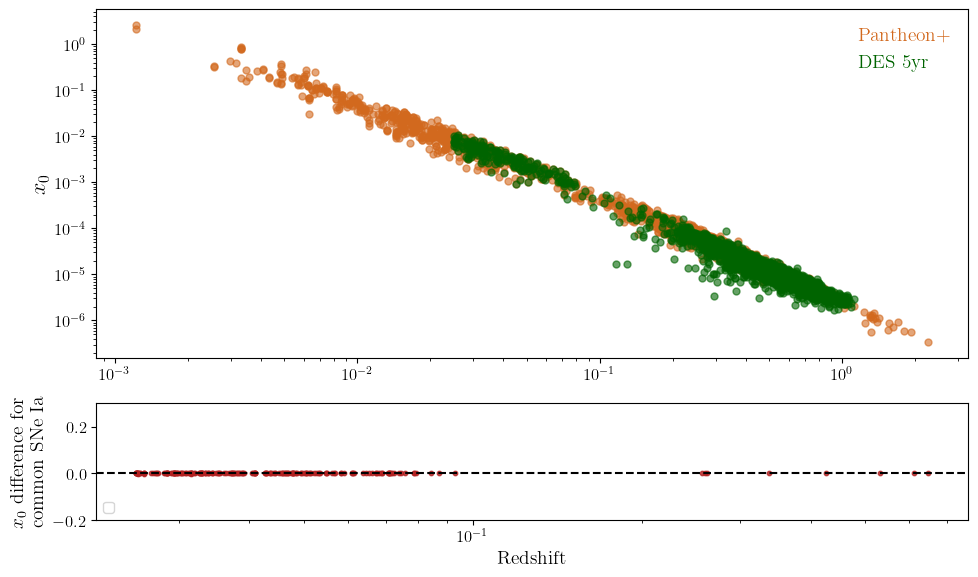

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(data_Pan['zHD'], data_Pan['x0'], 'o', label='Pantheon+', markersize=5, color='chocolate', alpha=0.6)
ax1.plot(data_DES['zHD'], data_DES['x0'], 'o', label='DES 5yr', markersize=5, color='darkgreen', alpha=0.6)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel(r'$x_0$', fontsize=16)
ax1.legend(fontsize=16)
leg = ax1.legend(handles=custom_handles, handlelength=0, handletextpad=0.1, frameon=False)

for text, color in zip(leg.get_texts(), colors):
    text.set_color(color)


ax2.scatter(common_data['zHD'], common_data['x0_Pan'] - common_data['x0_DES'], color='firebrick', s=10, alpha=0.8)
ax2.axhline(0, color='black', linestyle='--')  
ax2.set_xscale('log')
ax2.set_ylim(-0.2, 0.3)
ax2.set_xlabel('Redshift')
ax2.set_ylabel(r'$x_0$ difference for' '\n' 'common SNe Ia')
ax2.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig(text_folder + 'x0_parameter.png', dpi=300, bbox_inches='tight')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


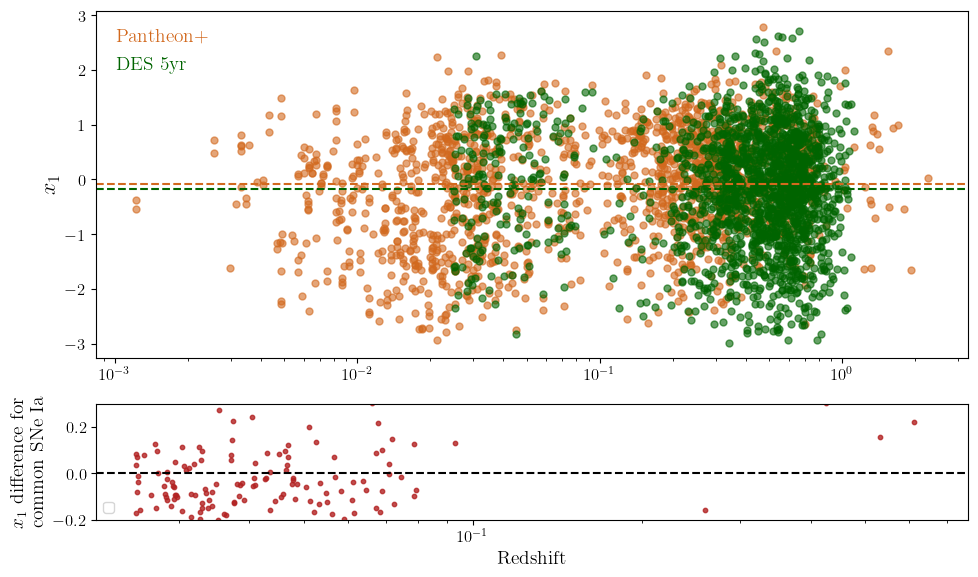

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(data_Pan['zHD'], data_Pan['x1'], 'o', label='Pantheon+', markersize=5, color='chocolate', alpha=0.6)
ax1.plot(data_DES['zHD'], data_DES['x1'], 'o', label='DES 5yr', markersize=5, color='darkgreen', alpha=0.6)
ax1.axhline(y=np.mean(data_Pan['x1']), color='chocolate', linestyle='--')
ax1.axhline(y=np.mean(data_DES['x1']), color='darkgreen', linestyle='--')
ax1.set_xscale('log')
ax1.set_ylabel(r'$x_1$', fontsize=16)
ax1.legend(fontsize=16)
leg = ax1.legend(handles=custom_handles, handlelength=0, handletextpad=0.1, frameon=False)

for text, color in zip(leg.get_texts(), colors):
    text.set_color(color)

ax2.scatter(common_data['zHD'], common_data['x1_Pan'] - common_data['x1_DES'], color='firebrick', s=10, alpha=0.8)
ax2.axhline(0, color='black', linestyle='--')  # Línea en y=0 para referencia
ax2.set_xscale('log')
ax2.set_ylim(-0.2, 0.3)
ax2.set_xlabel('Redshift')
ax2.set_ylabel(r'$x_1$ difference for' '\n' 'common SNe Ia')
ax2.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig(text_folder + 'x1_parameter.png', dpi=300, bbox_inches='tight')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


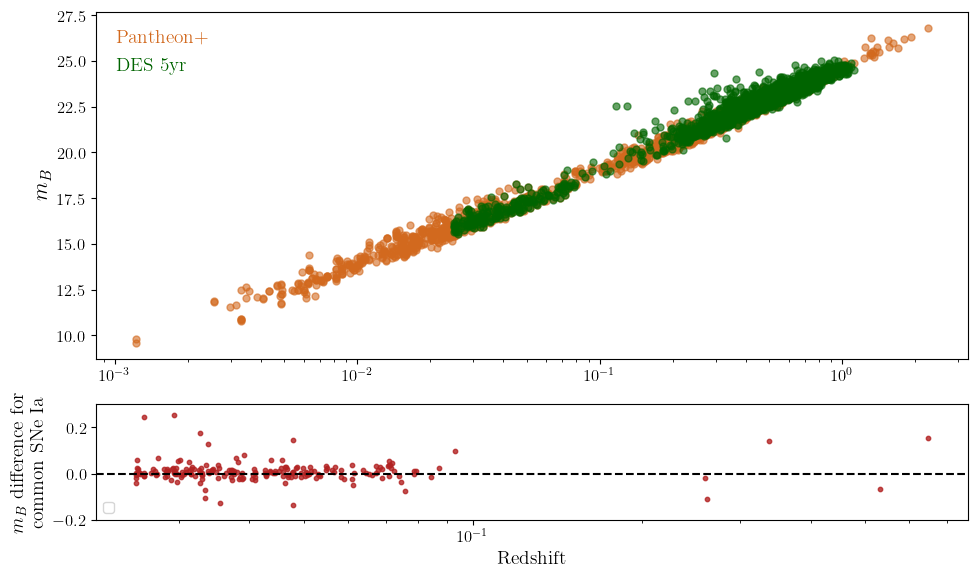

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(data_Pan['zHD'], data_Pan['mB'], 'o', label='Pantheon+', markersize=5, color='chocolate', alpha=0.6)
ax1.plot(data_DES['zHD'], data_DES['mB'], 'o', label='DES 5yr', markersize=5, color='darkgreen', alpha=0.6)
ax1.set_xscale('log')
ax1.set_ylabel(r'$m_B$', fontsize=16)
ax1.legend(fontsize=16)
leg = ax1.legend(handles=custom_handles, handlelength=0, handletextpad=0.1, frameon=False)

for text, color in zip(leg.get_texts(), colors):
    text.set_color(color)

ax2.scatter(common_data['zHD'], common_data['mB_Pan'] - common_data['mB_DES'], color='firebrick', s=10, alpha=0.8)
ax2.axhline(0, color='black', linestyle='--')  # Línea en y=0 para referencia
ax2.set_xscale('log')
ax2.set_ylim(-0.2, 0.3)
ax2.set_xlabel('Redshift')
ax2.set_ylabel(r'$m_B$ difference for' '\n' 'common SNe Ia')
ax2.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig(text_folder + 'mB_parameter.png', dpi=300, bbox_inches='tight')
plt.show()

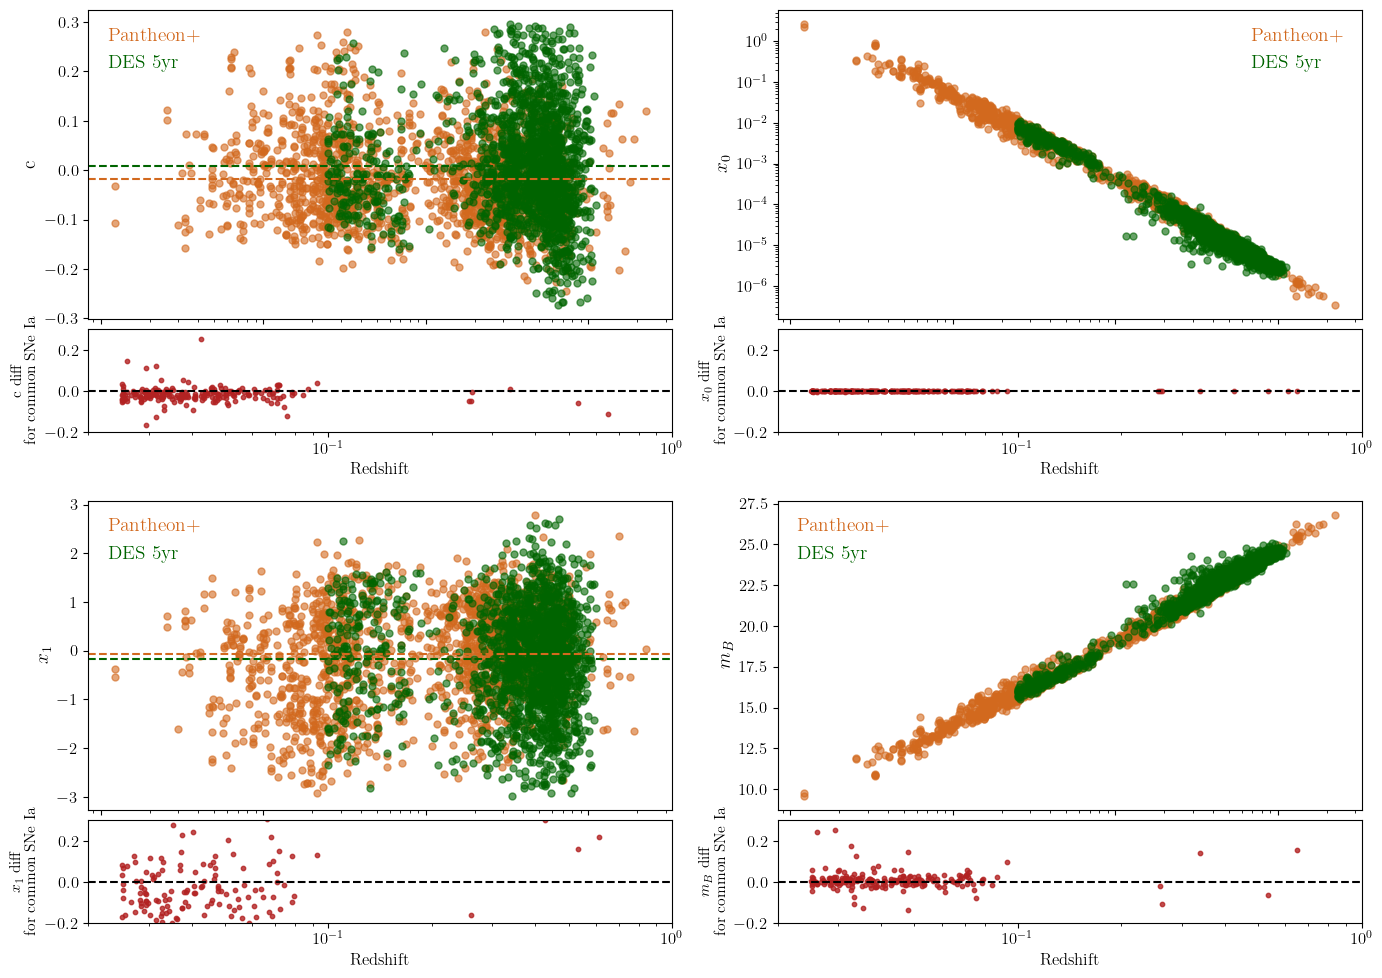

In [16]:
# 2x2 comparison of fitted parameters vs redshift with difference plots for common SNe
fig2 = plt.figure(figsize=(14, 10))
gs = fig2.add_gridspec(2, 2)

panels = [
    ('c', r'c', True),
    ('x0', r'$x_0$', False),
    ('x1', r'$x_1$', True),
    ('mB', r'$m_B$', False),
]

for idx, (col, ylabel, show_mean) in enumerate(panels):
    i, j = divmod(idx, 2)
    sub = gs[i, j].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax_top = fig2.add_subplot(sub[0])
    ax_bot = fig2.add_subplot(sub[1])

    ax_top.plot(data_Pan['zHD'], data_Pan[col], 'o', markersize=5, color='chocolate', 
                alpha=0.6, label='Pantheon+')
    ax_top.plot(data_DES['zHD'], data_DES[col], 'o', markersize=5, color='darkgreen', 
                alpha=0.6, label='DES 5yr')

    if show_mean:
        ax_top.axhline(y=np.mean(data_Pan[col]), color='chocolate', linestyle='--')
        ax_top.axhline(y=np.mean(data_DES[col]), color='darkgreen', linestyle='--')

    if col == 'x0':
        ax_top.set_yscale('log')

    ax_top.set_xscale('log')
    ax_top.set_ylabel(ylabel, fontsize=14)
    ax_top.tick_params(labelbottom=False)
    
    leg = ax_top.legend(handles=custom_handles, handlelength=0, handletextpad=0.1, 
                        frameon=False)
    for text, color in zip(leg.get_texts(), colors):
        text.set_color(color)

    # Plot differences for common SNe
    diff_col = f"{col}_Pan"
    diff_col_des = f"{col}_DES"
    
    if diff_col in common_data.columns and diff_col_des in common_data.columns:
        diffs = common_data[diff_col] - common_data[diff_col_des]
        ax_bot.scatter(common_data['zHD'], diffs, color='firebrick', s=10, alpha=0.8)

    ax_bot.axhline(0, color='black', linestyle='--')
    ax_bot.set_xscale('log')
    ax_bot.set_xlim(0.02, 1)
    ax_bot.set_ylim(-0.2, 0.3)
    ax_bot.set_xlabel('Redshift', fontsize=12)
    ax_bot.set_ylabel(f'{ylabel} diff\nfor common SNe Ia', fontsize=11)

plt.tight_layout()
plt.savefig(text_folder + 'parameters_2x2.png', dpi=300, bbox_inches='tight')
plt.show()


# Modulus comparision

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


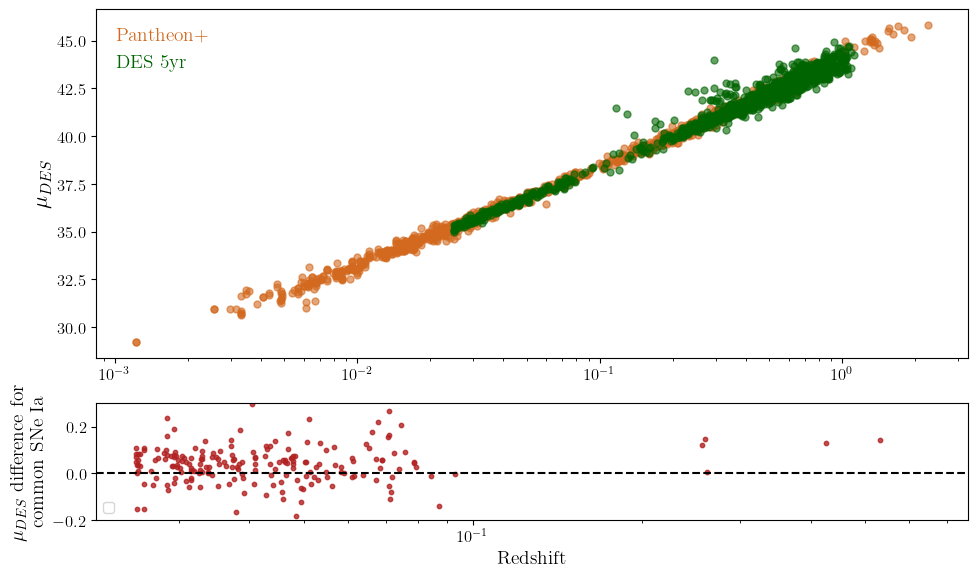

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(data_Pan['zHD'], data_Pan['MU_DES'], 'o', label='Pantheon+', markersize=5, color='chocolate', alpha=0.6)
ax1.plot(data_DES['zHD'], data_DES['MU_DES'], 'o', label='DES 5yr', markersize=5, color='darkgreen', alpha=0.6)
ax1.set_xscale('log')
ax1.set_ylabel(r'$\mu_{DES}$', fontsize=16)
ax1.legend(fontsize=16)
leg = ax1.legend(handles=custom_handles, handlelength=0, handletextpad=0.1, frameon=False)

for text, color in zip(leg.get_texts(), colors):
    text.set_color(color)

ax2.scatter(common_data['zHD'], common_data['MU_DES_Pan'] - common_data['MU_DES_DES'], color='firebrick', s=10, alpha=0.8)
ax2.axhline(0, color='black', linestyle='--')  # Línea en y=0 para referencia
ax2.set_xscale('log')
ax2.set_ylim(-0.2, 0.3)
ax2.set_xlabel('Redshift')
ax2.set_ylabel(r'$\mu_{DES}$ difference for' '\n' 'common SNe Ia')
ax2.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig(text_folder + 'mu_comparision_DES.png', dpi=300, bbox_inches='tight')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


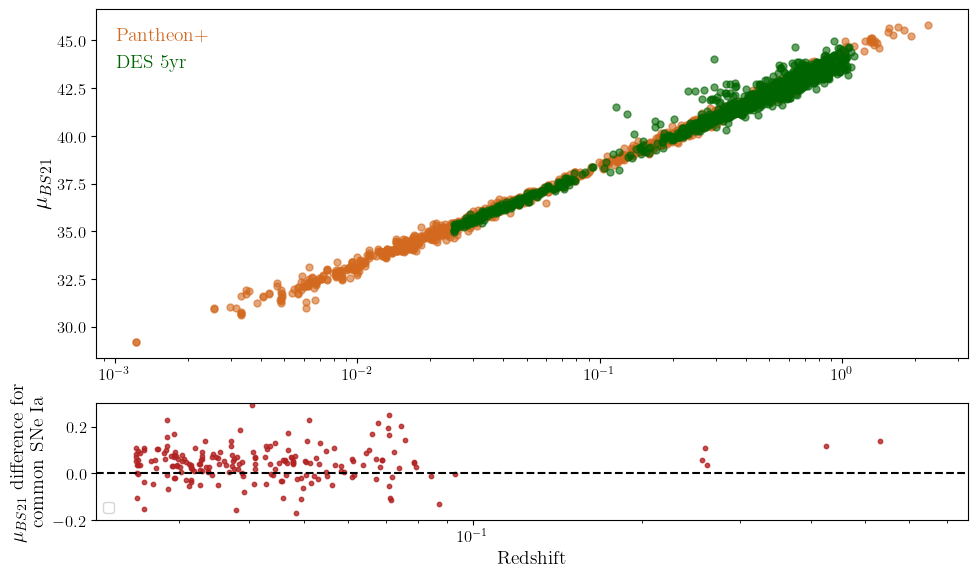

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(data_Pan['zHD'], data_Pan['MU_BS21'], 'o', label='Pantheon+', markersize=5, color='chocolate', alpha=0.6)
ax1.plot(data_DES['zHD'], data_DES['MU_BS21'], 'o', label='DES 5yr', markersize=5, color='darkgreen', alpha=0.6)
ax1.set_xscale('log')
ax1.set_ylabel(r'$\mu_{BS21}$', fontsize=16)
ax1.legend(fontsize=16)
leg = ax1.legend(handles=custom_handles, handlelength=0, handletextpad=0.1, frameon=False)

for text, color in zip(leg.get_texts(), colors):
    text.set_color(color)

ax2.scatter(common_data['zHD'], common_data['MU_BS21_Pan'] - common_data['MU_BS21_DES'], color='firebrick', s=10, alpha=0.8)
ax2.axhline(0, color='black', linestyle='--')  # Línea en y=0 para referencia
ax2.set_xscale('log')
ax2.set_ylim(-0.2, 0.3)
ax2.set_xlabel('Redshift')
ax2.set_ylabel(r'$\mu_{BS21}$ difference for' '\n' 'common SNe Ia')
ax2.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig(text_folder + 'mu_comparision_BS21.png', dpi=300, bbox_inches='tight')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


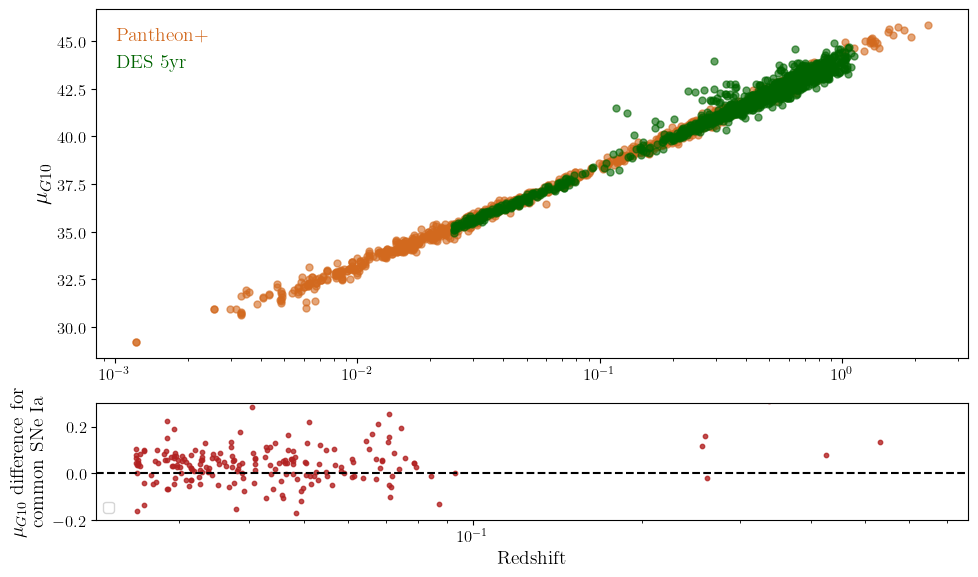

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(data_Pan['zHD'], data_Pan['MU_G10'], 'o', label='Pantheon+', markersize=5, color='chocolate', alpha=0.6)
ax1.plot(data_DES['zHD'], data_DES['MU_G10'], 'o', label='DES 5yr', markersize=5, color='darkgreen', alpha=0.6)
ax1.set_xscale('log')
ax1.set_ylabel(r'$\mu_{G10}$', fontsize=16)
ax1.legend(fontsize=16)
leg = ax1.legend(handles=custom_handles, handlelength=0, handletextpad=0.1, frameon=False)

for text, color in zip(leg.get_texts(), colors):
    text.set_color(color)

ax2.scatter(common_data['zHD'], common_data['MU_G10_Pan'] - common_data['MU_G10_DES'], color='firebrick', s=10, alpha=0.8)
ax2.axhline(0, color='black', linestyle='--')  # Línea en y=0 para referencia
ax2.set_xscale('log')
ax2.set_ylim(-0.2, 0.3)
ax2.set_xlabel('Redshift')
ax2.set_ylabel(r'$\mu_{G10}$ difference for' '\n' 'common SNe Ia')
ax2.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig(text_folder + 'mu_comparision_G10.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_32579/2218365744.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


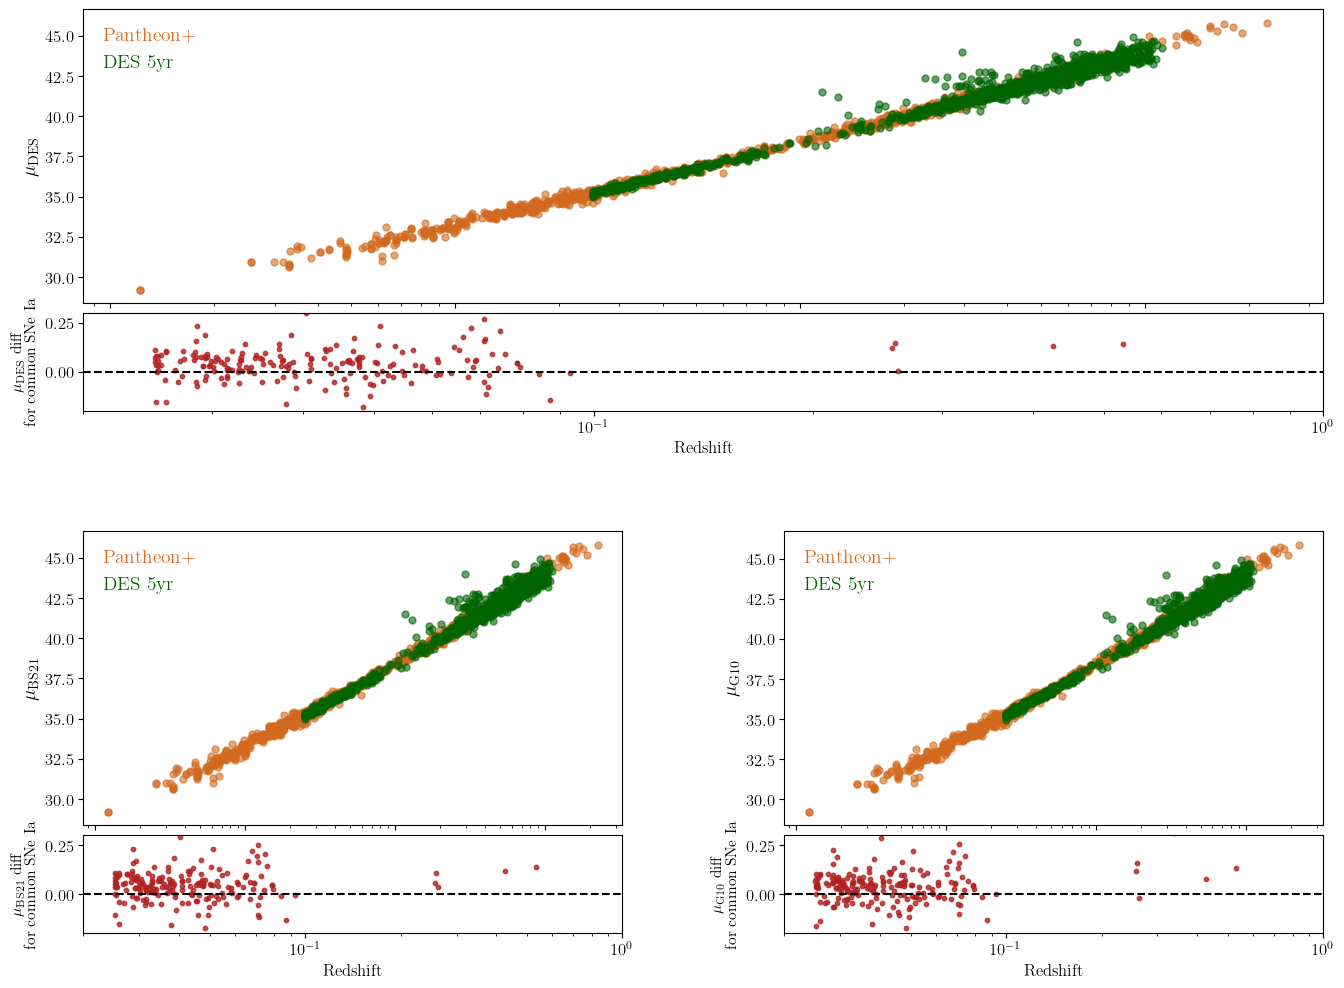

In [23]:
# 1+2 grid comparison of distance modulus for three models with difference plots
fig3 = plt.figure(figsize=(16, 12))
gs = fig3.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.3)

models = [
    ('MU_DES', r'$\mu_{\rm DES}$'),
    ('MU_BS21', r'$\mu_{\rm BS21}$'),
    ('MU_G10', r'$\mu_{\rm G10}$')
]

# Top panel - first model spanning full width
sub_top = gs[0, :].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax_top = fig3.add_subplot(sub_top[0])
ax_bot = fig3.add_subplot(sub_top[1])

mu_col, ylabel = models[0]
ax_top.plot(data_Pan['zHD'], data_Pan[mu_col], 'o', markersize=5, color='chocolate', alpha=0.6)
ax_top.plot(data_DES['zHD'], data_DES[mu_col], 'o', markersize=5, color='darkgreen', alpha=0.6)
ax_top.set_xscale('log')
ax_top.set_ylabel(ylabel, fontsize=14)
ax_top.tick_params(labelbottom=False)

leg = ax_top.legend(handles=custom_handles, handlelength=0, handletextpad=0.1, frameon=False)
for text, color in zip(leg.get_texts(), colors):
    text.set_color(color)

diff_col_pan = f"{mu_col}_Pan"
diff_col_des = f"{mu_col}_DES"
if diff_col_pan in common_data.columns and diff_col_des in common_data.columns:
    diffs = common_data[diff_col_pan] - common_data[diff_col_des]
    ax_bot.scatter(common_data['zHD'], diffs, color='firebrick', s=10, alpha=0.8)

ax_bot.axhline(0, color='black', linestyle='--')
ax_bot.set_xscale('log')
ax_bot.set_xlim(0.02, 1)
ax_bot.set_ylim(-0.2, 0.3)
ax_bot.set_xlabel('Redshift', fontsize=12)
ax_bot.set_ylabel(f'{ylabel} diff\nfor common SNe Ia', fontsize=11)

# Bottom panels - second and third models side by side
for idx in range(1, 3):
    col_idx = idx - 1
    sub_bottom = gs[1, col_idx].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax_top = fig3.add_subplot(sub_bottom[0])
    ax_bot = fig3.add_subplot(sub_bottom[1])
    
    mu_col, ylabel = models[idx]
    ax_top.plot(data_Pan['zHD'], data_Pan[mu_col], 'o', markersize=5, color='chocolate', alpha=0.6)
    ax_top.plot(data_DES['zHD'], data_DES[mu_col], 'o', markersize=5, color='darkgreen', alpha=0.6)
    ax_top.set_xscale('log')
    ax_top.set_ylabel(ylabel, fontsize=14)
    ax_top.tick_params(labelbottom=False)
    
    leg = ax_top.legend(handles=custom_handles, handlelength=0, handletextpad=0.1, frameon=False)
    for text, color in zip(leg.get_texts(), colors):
        text.set_color(color)
    
    diff_col_pan = f"{mu_col}_Pan"
    diff_col_des = f"{mu_col}_DES"
    if diff_col_pan in common_data.columns and diff_col_des in common_data.columns:
        diffs = common_data[diff_col_pan] - common_data[diff_col_des]
        ax_bot.scatter(common_data['zHD'], diffs, color='firebrick', s=10, alpha=0.8)
    
    ax_bot.axhline(0, color='black', linestyle='--')
    ax_bot.set_xscale('log')
    ax_bot.set_xlim(0.02, 1)
    ax_bot.set_ylim(-0.2, 0.3)
    ax_bot.set_xlabel('Redshift', fontsize=12)
    ax_bot.set_ylabel(f'{ylabel} diff\nfor common SNe Ia', fontsize=11)

plt.tight_layout()
plt.savefig(text_folder + 'modulus_comparison_1x3.png', dpi=300, bbox_inches='tight')
plt.show()

# MCMC results

In [21]:
#Define parameter names and labels
param_names = ['om_m', 'H0']  
labels = [r'\Omega_m', r'H_0']

#data import from MCMC chains
data_Pan_DES_mag = np.loadtxt("samples_Pan_DES_mag_mb.txt")
data_Pan_DES_nomag = np.loadtxt("samples_Pan_DES_nomag_mb.txt")
data_Pan_BS21_mag = np.loadtxt("samples_Pan_BS21_mag_mb.txt")
data_Pan_BS21_nomag = np.loadtxt("samples_Pan_BS21_nomag_mb.txt")
data_Pan_G10_mag = np.loadtxt("samples_Pan_G10_mag_mb.txt")
data_Pan_G10_nomag = np.loadtxt("samples_Pan_G10_nomag_mb.txt")

data_DES_DES_mag = np.loadtxt("samples_DES_DES_mag_mb.txt")
data_DES_DES_nomag = np.loadtxt("samples_DES_DES_nomag_mb.txt")
data_DES_BS21_mag = np.loadtxt("samples_DES_BS21_mag_mb.txt")
data_DES_BS21_nomag = np.loadtxt("samples_DES_BS21_nomag_mb.txt")
data_DES_G10_mag = np.loadtxt("samples_DES_G10_mag_mb.txt")
data_DES_G10_nomag = np.loadtxt("samples_DES_G10_nomag_mb.txt")

#Convert it into MCSamples object
samples_Pan_DES_mag = MCSamples(samples=data_Pan_DES_mag, names=param_names, labels=labels)
samples_Pan_DES_nomag = MCSamples(samples=data_Pan_DES_nomag, names=param_names, labels=labels)
samples_Pan_BS21_mag = MCSamples(samples=data_Pan_BS21_mag, names=param_names, labels=labels)
samples_Pan_BS21_nomag = MCSamples(samples=data_Pan_BS21_nomag, names=param_names, labels=labels)
samples_Pan_G10_mag = MCSamples(samples=data_Pan_G10_mag, names=param_names, labels=labels)
samples_Pan_G10_nomag = MCSamples(samples=data_Pan_G10_nomag, names=param_names, labels=labels)

samples_DES_DES_mag = MCSamples(samples=data_DES_DES_mag, names=param_names, labels=labels)
samples_DES_DES_nomag = MCSamples(samples=data_DES_DES_nomag, names=param_names, labels=labels)
samples_DES_BS21_mag = MCSamples(samples=data_DES_BS21_mag, names=param_names, labels=labels)
samples_DES_BS21_nomag = MCSamples(samples=data_DES_BS21_nomag, names=param_names, labels=labels)
samples_DES_G10_mag = MCSamples(samples=data_DES_G10_mag, names=param_names, labels=labels)
samples_DES_G10_nomag = MCSamples(samples=data_DES_G10_nomag, names=param_names, labels=labels)

# Function to summarize MCSamples
def summarize_mc_samples(mc_sample, sample_name):
    """
    Print mean ± standard deviation for each parameter in an MCSamples object.
    
    Parameters
    ----------
    mc_sample : MCSamples
        MCSamples object containing the MCMC samples.
    """
    param_names = mc_sample.getParamNames().names
    for name in param_names:
        mean = mc_sample.mean(name)
        err = mc_sample.std(name)
        print(f"{sample_name} - {name}: {mean:.4f} ± {err:.4f}")

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


DES param on DES5yr - om_m	\Omega_m: 0.3799 ± 0.0256
DES param on DES5yr - H0	H_0: 68.1239 ± 0.5471
DES param on Pantheon+ - om_m	\Omega_m: 0.3506 ± 0.0406
DES param on Pantheon+ - H0	H_0: 67.5581 ± 0.5166


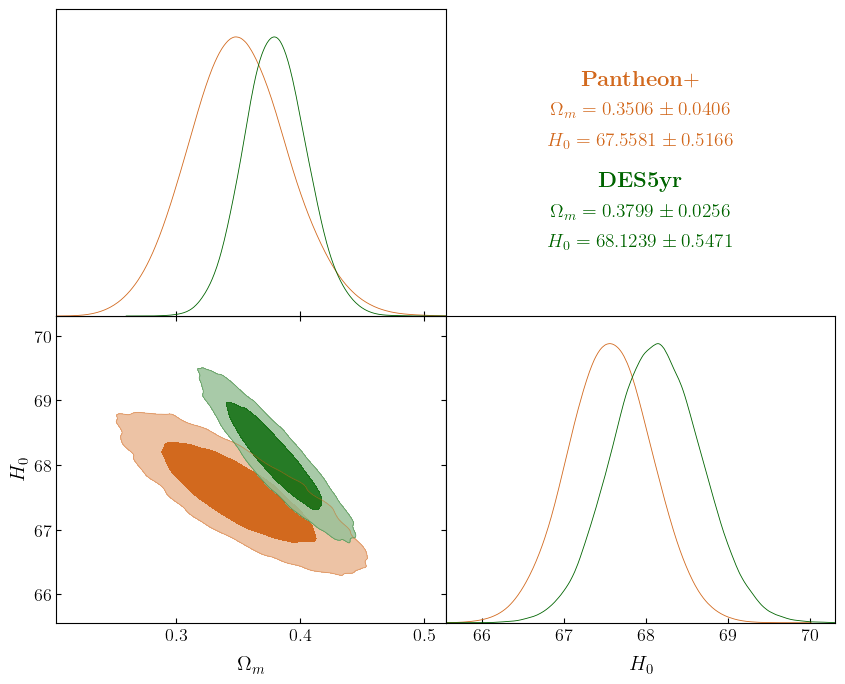

In [22]:
mm.make_triangle_plot(
    [samples_Pan_DES_mag, samples_DES_DES_mag],
    labels=labels,
    colors=('chocolate', 'darkgreen'),
    outfile=text_folder + 'DESparams_mag.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['Pantheon+', 'DES 5yr']
)

summarize_mc_samples(samples_DES_DES_mag, sample_name='DES param on DES5yr')
summarize_mc_samples(samples_Pan_DES_mag, sample_name='DES param on Pantheon+')

DES param on DES5yr - om_m	\Omega_m: 0.1000 ± 0.0000
DES param on DES5yr - H0	H_0: 10.0000 ± 0.0000
DES param on Pantheon+ - om_m	\Omega_m: 0.1000 ± 0.0000
DES param on Pantheon+ - H0	H_0: 10.0001 ± 0.0001


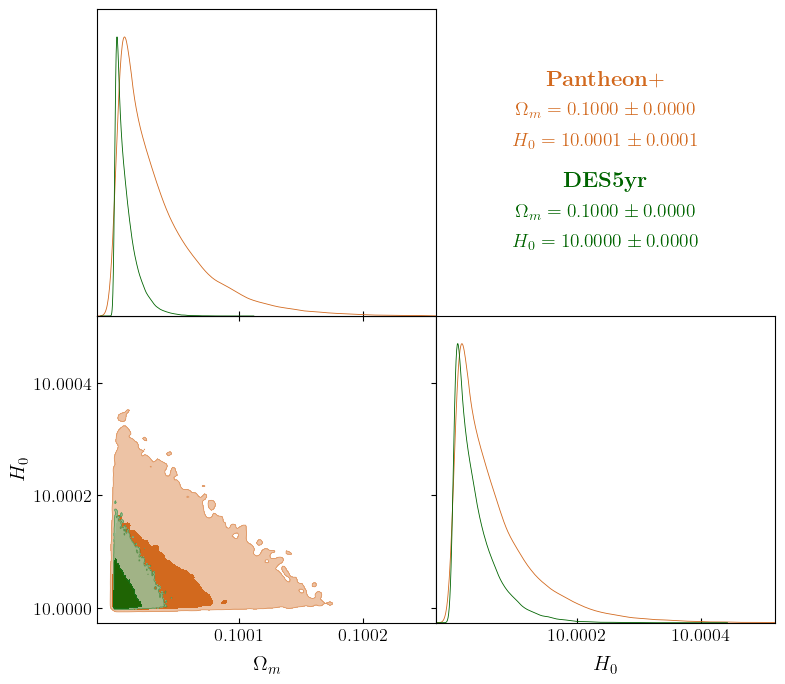

In [16]:
mm.make_triangle_plot(
    [samples_Pan_DES_nomag, samples_DES_DES_nomag],
    labels=labels,
    colors=('chocolate', 'darkgreen'),
    outfile=text_folder + 'DESparams_nomag.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['Pantheon+', 'DES 5yr']
)

summarize_mc_samples(samples_DES_DES_nomag, sample_name='DES param on DES5yr')
summarize_mc_samples(samples_Pan_DES_nomag, sample_name='DES param on Pantheon+')

DES param on DES5yr - om_m	\Omega_m: 0.3794 ± 0.0258
DES param on DES5yr - H0	H_0: 68.2375 ± 0.5497
DES param on Pantheon+ - om_m	\Omega_m: 0.3546 ± 0.0414
DES param on Pantheon+ - H0	H_0: 67.6183 ± 0.5236


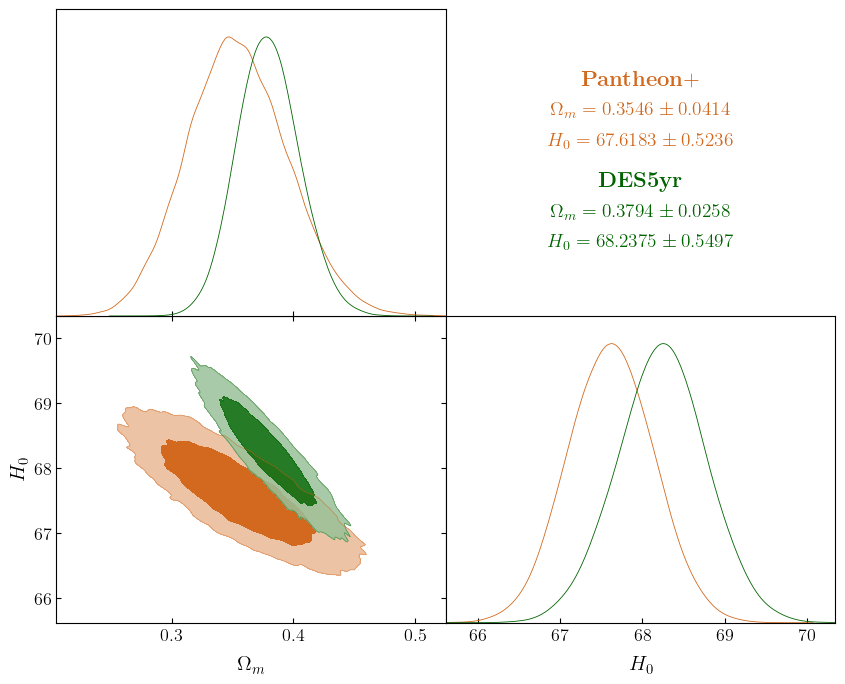

In [17]:
mm.make_triangle_plot(
    [samples_Pan_BS21_mag, samples_DES_BS21_mag],
    labels=labels,
    colors=('chocolate', 'darkgreen'),
    outfile=text_folder + 'BS21params_mag.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['Pantheon+', 'DES 5yr']
)

summarize_mc_samples(samples_DES_BS21_mag, sample_name='DES param on DES5yr')
summarize_mc_samples(samples_Pan_BS21_mag, sample_name='DES param on Pantheon+')

DES param on DES5yr - om_m	\Omega_m: 0.1000 ± 0.0000
DES param on DES5yr - H0	H_0: 10.0000 ± 0.0000
DES param on Pantheon+ - om_m	\Omega_m: 0.1000 ± 0.0000
DES param on Pantheon+ - H0	H_0: 10.0001 ± 0.0001


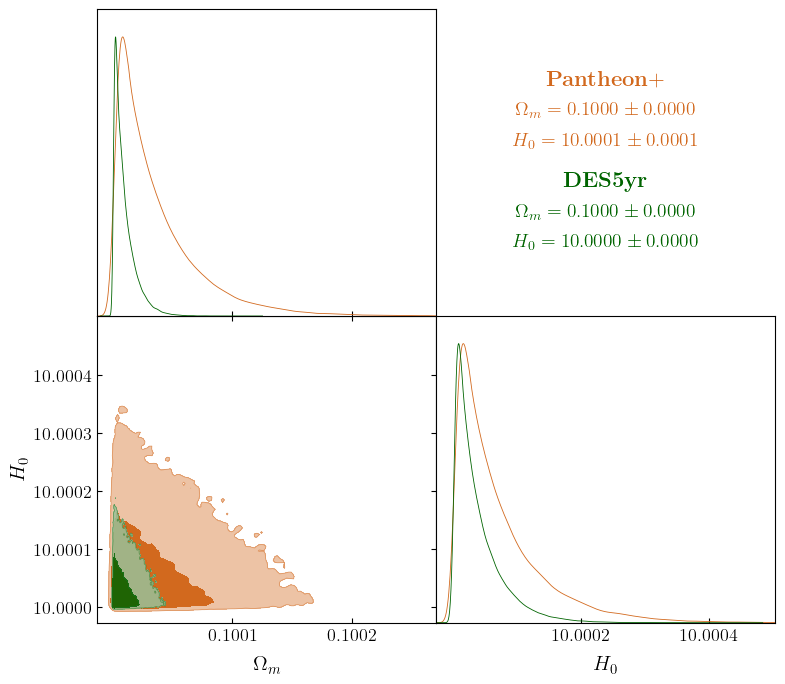

In [18]:
mm.make_triangle_plot(
    [samples_Pan_BS21_nomag, samples_DES_BS21_nomag],
    labels=labels,
    colors=('chocolate', 'darkgreen'),
    outfile=text_folder + 'BS21params_nomag.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['Pantheon+', 'DES 5yr']
)

summarize_mc_samples(samples_DES_BS21_nomag, sample_name='DES param on DES5yr')
summarize_mc_samples(samples_Pan_BS21_nomag, sample_name='DES param on Pantheon+')

DES param on DES5yr - om_m	\Omega_m: 0.3812 ± 0.0258
DES param on DES5yr - H0	H_0: 68.0975 ± 0.5455
DES param on Pantheon+ - om_m	\Omega_m: 0.3600 ± 0.0411
DES param on Pantheon+ - H0	H_0: 67.5751 ± 0.5231


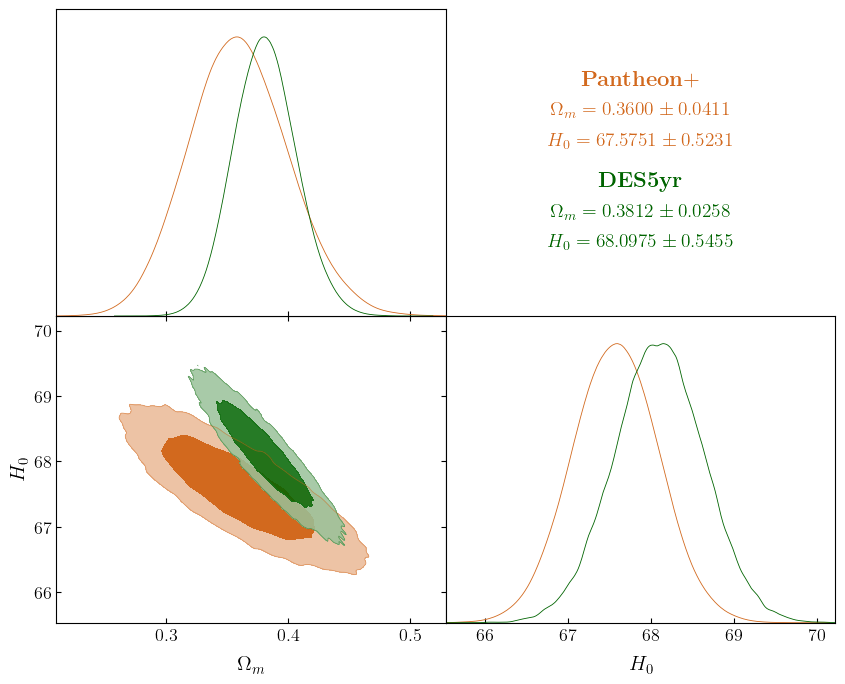

In [19]:
mm.make_triangle_plot(
    [samples_Pan_G10_mag, samples_DES_G10_mag],
    labels=labels,
    colors=('chocolate', 'darkgreen'),
    outfile=text_folder + 'G10params_mag.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['Pantheon+', 'DES 5yr']
)

summarize_mc_samples(samples_DES_G10_mag, sample_name='DES param on DES5yr')
summarize_mc_samples(samples_Pan_G10_mag, sample_name='DES param on Pantheon+')

DES param on DES5yr - om_m	\Omega_m: 0.1000 ± 0.0000
DES param on DES5yr - H0	H_0: 10.0000 ± 0.0000
DES param on Pantheon+ - om_m	\Omega_m: 0.1000 ± 0.0000
DES param on Pantheon+ - H0	H_0: 10.0001 ± 0.0001


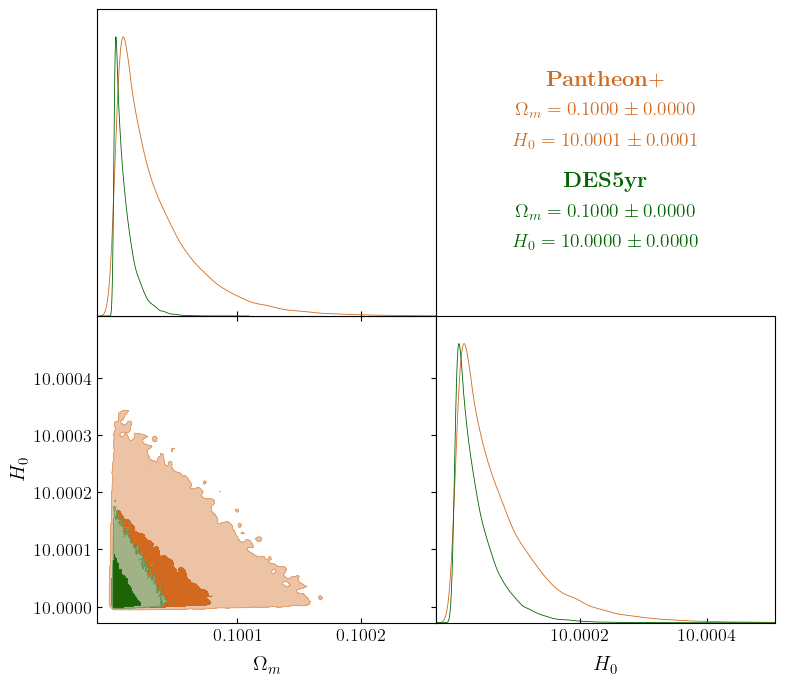

In [20]:
mm.make_triangle_plot(
    [samples_Pan_G10_nomag, samples_DES_G10_nomag],
    labels=labels,
    colors=('chocolate', 'darkgreen'),
    outfile=text_folder + 'G10params_nomag.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['Pantheon+', 'DES 5yr']
)

summarize_mc_samples(samples_DES_G10_nomag, sample_name='DES param on DES5yr')
summarize_mc_samples(samples_Pan_G10_nomag, sample_name='DES param on Pantheon+')